In [1]:
# Read in library clusters from SLUG
import numpy as np
# import numexpr as ne
import os 
import os.path as osp
import random
import time
import glob
import copy
from collections import namedtuple
from numpy.random import seed, rand
from slugpy.cluster_slug import cluster_slug
from slugpy import slug_pdf, read_cluster
from slugpy import photometry_convert 
from datetime import date
import sys  
from datetime import date
import numpy as np
from astropy.io import fits
import os 
import matplotlib.pyplot as plt
import re 

In [2]:
main_dir = "/g/data/jh2/jt4478/make_LC_copy"
os.chdir(main_dir)
# define constants 
processes = []
PSFpath = '/g/data/jh2/jt4478/PSF_all'
baopath = '/g/data/jh2/jt4478/baolab-0.94.1g/'
galaxies = np.load(os.path.join(main_dir, 'galaxy_names.npy'))
gal_filters = np.load('galaxy_filter_dict.npy', allow_pickle=True).item()
nsf =  True
pixscale_wfc3 = 0.04
pixscale_acs = 0.05
# maglim = array([18, 26], dtype=float)
merr_cut = 0.3 # change to 0.5 
binsize = 0.3
nums_perframe = 500
sigma_pc = 100 # physical size of Gaussian filter for distributing clusters on sci frame
xcol=0            #specifies which column in the data contains the x-coordinates 
ycol=1            #specifies which column in the data contains the x-coordinates 
tolerance = 3 # tolerance in units of px, testing 5 pixels 
minsep = False
maglim = [18,26]
cams = gal_filters['ngc628-c']
minsep = False
nsf=True
use_white_pos = True 
white_dir = '/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100/white'

In [3]:
# load validation set first 

In [3]:
import numpy as np
import os
import glob
from scipy.spatial import cKDTree

# Constants
nframe_start = 0
nframe_end = 100
nframe = nframe_end-nframe_start
reff = 10
x_white = 500
thres_coor = 3
outname = 'tset_18Dec'
detection_white = np.full((x_white, nframe, reff), 0, dtype=np.uint8)
validation = True
framenum = 24
# Directories
dire = '/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100/white/s_extraction'
dw = '/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100/white'
outdir = os.path.join(dw, "matched_coords")
os.makedirs(outdir, exist_ok=True)
# sex_ngc628-c_WFC3_UVISfF336W_frame0_vframe_99_vset_4Nov_validation_reff9.00.fits.coo
# white_position_5_vframe_99_vset_4Nov_validation_reff1.00.txt
# --- Loop over frames and radii ---
for re in range(1, reff + 1):
    for f in range(nframe_start, nframe_end):
        if validation:
            sex_cfiles = glob.glob(os.path.join(
                dire, f'sex_ngc628-c_WFC3_UVISfF336W_frame{framenum}_vframe_{f}_{outname}_validation_reff{re:.2f}.fits.coo'))
            
        else:
            sex_cfiles = glob.glob(os.path.join(
                dire, f'sex_ngc628-c_WFC3_UVISfF336W_frame{f}_{outname}_reff{re:.2f}.fits.coo'))
        if validation:
            syn_cfiles = glob.glob(os.path.join(
                dw, f'white_position_{framenum}_vframe_{f}_{outname}_validation_reff{re:.2f}.txt'))
        else:
            syn_cfiles = glob.glob(os.path.join(
                dw, f'white_position_{f}_{outname}_reff{re:.2f}.txt'))

        if not sex_cfiles or not syn_cfiles:
            continue
            print('no file.')

        sex_c = np.loadtxt(sex_cfiles[0])
        syn_c = np.loadtxt(syn_cfiles[0])

        # Coordinates
        x_v, y_v = sex_c[:, 0], sex_c[:, 1]
        x_s, y_s = syn_c[:, 0], syn_c[:, 1]

        # Build KDTree for detections
        tree = cKDTree(np.column_stack((x_v, y_v)))

        # Query nearest neighbor for each synthetic point
        dist, idx = tree.query(np.column_stack((x_s, y_s)), distance_upper_bound=thres_coor)

        # Keep only valid matches (within threshold)
        mask = np.isfinite(dist) & (dist < thres_coor)
        detection_white[:len(mask), f, re - 1] = mask.astype(np.uint8)

        # Extract matched coordinates in sex_c
        matched_coords = sex_c[idx[mask].astype(int)]

        # Save for later use
        if not validation:
            if matched_coords.size > 0:
                np.savetxt(
                    os.path.join(outdir, f"matched_frame{f}_{outname}_reff{re:.2f}.txt"),
                    matched_coords,
                    fmt="%.6f"
                )

            print(f"[Frame {f:03d}, reff {re:02d}] matched {mask.sum()} / {len(mask)}")
        else:
            if matched_coords.size > 0:
                np.savetxt(
                    os.path.join(outdir, f"matched_frame{framenum}_vframe{f}_{outname}_reff{re:.2f}.txt"),
                    matched_coords,
                    fmt="%.6f"
                )

            print(f"[Frame {f:03d}, reff {re:02d}] matched {mask.sum()} / {len(mask)}")

print("✅ Done. detection_white shape =", detection_white.shape)


[Frame 000, reff 01] matched 152 / 500
[Frame 001, reff 01] matched 153 / 500
[Frame 002, reff 01] matched 153 / 500
[Frame 003, reff 01] matched 146 / 500
[Frame 004, reff 01] matched 154 / 500
[Frame 005, reff 01] matched 152 / 500
[Frame 006, reff 01] matched 154 / 500
[Frame 007, reff 01] matched 157 / 500
[Frame 008, reff 01] matched 153 / 500
[Frame 009, reff 01] matched 152 / 500
[Frame 010, reff 01] matched 158 / 500
[Frame 011, reff 01] matched 155 / 500
[Frame 012, reff 01] matched 163 / 500
[Frame 013, reff 01] matched 152 / 500
[Frame 014, reff 01] matched 154 / 500
[Frame 015, reff 01] matched 157 / 500
[Frame 016, reff 01] matched 156 / 500
[Frame 017, reff 01] matched 158 / 500
[Frame 018, reff 01] matched 151 / 500
[Frame 019, reff 01] matched 151 / 500
[Frame 020, reff 01] matched 160 / 500
[Frame 021, reff 01] matched 157 / 500
[Frame 022, reff 01] matched 157 / 500
[Frame 023, reff 01] matched 155 / 500
[Frame 024, reff 01] matched 149 / 500
[Frame 025, reff 01] matc

[Frame 011, reff 03] matched 302 / 500
[Frame 012, reff 03] matched 299 / 500
[Frame 013, reff 03] matched 301 / 500
[Frame 014, reff 03] matched 304 / 500
[Frame 015, reff 03] matched 300 / 500
[Frame 016, reff 03] matched 298 / 500
[Frame 017, reff 03] matched 300 / 500
[Frame 018, reff 03] matched 302 / 500
[Frame 019, reff 03] matched 303 / 500
[Frame 020, reff 03] matched 299 / 500
[Frame 021, reff 03] matched 306 / 500
[Frame 022, reff 03] matched 302 / 500
[Frame 023, reff 03] matched 302 / 500
[Frame 024, reff 03] matched 299 / 500
[Frame 025, reff 03] matched 302 / 500
[Frame 026, reff 03] matched 299 / 500
[Frame 027, reff 03] matched 302 / 500
[Frame 028, reff 03] matched 306 / 500
[Frame 029, reff 03] matched 304 / 500
[Frame 030, reff 03] matched 297 / 500
[Frame 031, reff 03] matched 304 / 500
[Frame 032, reff 03] matched 303 / 500
[Frame 033, reff 03] matched 302 / 500
[Frame 034, reff 03] matched 298 / 500
[Frame 035, reff 03] matched 301 / 500
[Frame 036, reff 03] matc

[Frame 023, reff 05] matched 145 / 500
[Frame 024, reff 05] matched 144 / 500
[Frame 025, reff 05] matched 155 / 500
[Frame 026, reff 05] matched 150 / 500
[Frame 027, reff 05] matched 145 / 500
[Frame 028, reff 05] matched 150 / 500
[Frame 029, reff 05] matched 149 / 500
[Frame 030, reff 05] matched 144 / 500
[Frame 031, reff 05] matched 146 / 500
[Frame 032, reff 05] matched 145 / 500
[Frame 033, reff 05] matched 150 / 500
[Frame 034, reff 05] matched 154 / 500
[Frame 035, reff 05] matched 143 / 500
[Frame 036, reff 05] matched 151 / 500
[Frame 037, reff 05] matched 154 / 500
[Frame 038, reff 05] matched 149 / 500
[Frame 039, reff 05] matched 149 / 500
[Frame 040, reff 05] matched 151 / 500
[Frame 041, reff 05] matched 146 / 500
[Frame 042, reff 05] matched 151 / 500
[Frame 043, reff 05] matched 148 / 500
[Frame 044, reff 05] matched 148 / 500
[Frame 045, reff 05] matched 153 / 500
[Frame 046, reff 05] matched 156 / 500
[Frame 047, reff 05] matched 154 / 500
[Frame 048, reff 05] matc

[Frame 035, reff 07] matched 297 / 500
[Frame 036, reff 07] matched 300 / 500
[Frame 037, reff 07] matched 297 / 500
[Frame 038, reff 07] matched 300 / 500
[Frame 039, reff 07] matched 303 / 500
[Frame 040, reff 07] matched 299 / 500
[Frame 041, reff 07] matched 298 / 500
[Frame 042, reff 07] matched 299 / 500
[Frame 043, reff 07] matched 299 / 500
[Frame 044, reff 07] matched 300 / 500
[Frame 045, reff 07] matched 300 / 500
[Frame 046, reff 07] matched 300 / 500
[Frame 047, reff 07] matched 297 / 500
[Frame 048, reff 07] matched 299 / 500
[Frame 049, reff 07] matched 296 / 500
[Frame 050, reff 07] matched 302 / 500
[Frame 051, reff 07] matched 306 / 500
[Frame 052, reff 07] matched 302 / 500
[Frame 053, reff 07] matched 298 / 500
[Frame 054, reff 07] matched 297 / 500
[Frame 055, reff 07] matched 296 / 500
[Frame 056, reff 07] matched 306 / 500
[Frame 057, reff 07] matched 301 / 500
[Frame 058, reff 07] matched 302 / 500
[Frame 059, reff 07] matched 296 / 500
[Frame 060, reff 07] matc

[Frame 047, reff 09] matched 433 / 500
[Frame 048, reff 09] matched 434 / 500
[Frame 049, reff 09] matched 437 / 500
[Frame 050, reff 09] matched 438 / 500
[Frame 051, reff 09] matched 435 / 500
[Frame 052, reff 09] matched 438 / 500
[Frame 053, reff 09] matched 438 / 500
[Frame 054, reff 09] matched 442 / 500
[Frame 055, reff 09] matched 438 / 500
[Frame 056, reff 09] matched 441 / 500
[Frame 057, reff 09] matched 440 / 500
[Frame 058, reff 09] matched 438 / 500
[Frame 059, reff 09] matched 444 / 500
[Frame 060, reff 09] matched 445 / 500
[Frame 061, reff 09] matched 433 / 500
[Frame 062, reff 09] matched 441 / 500
[Frame 063, reff 09] matched 441 / 500
[Frame 064, reff 09] matched 438 / 500
[Frame 065, reff 09] matched 439 / 500
[Frame 066, reff 09] matched 434 / 500
[Frame 067, reff 09] matched 433 / 500
[Frame 068, reff 09] matched 440 / 500
[Frame 069, reff 09] matched 437 / 500
[Frame 070, reff 09] matched 437 / 500
[Frame 071, reff 09] matched 436 / 500
[Frame 072, reff 09] matc

In [4]:
import numpy as np
import os
import glob
from scipy.spatial import cKDTree

# Constants
nframe_start = 0
nframe_end = 160
nframe = nframe_end-nframe_start
reff = 10
x_white = 500
thres_coor = 3
outname = 'tset_18Dec'
detection_white = np.full((x_white, nframe, reff), 0, dtype=np.uint8)
validation = False
# framenum = 0
# Directories
dire = '/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100/white/s_extraction'
dw = '/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100/white'
outdir = os.path.join(dw, "matched_coords")
os.makedirs(outdir, exist_ok=True)
# sex_ngc628-c_WFC3_UVISfF336W_frame0_vframe_99_vset_4Nov_validation_reff9.00.fits.coo
# white_position_5_vframe_99_vset_4Nov_validation_reff1.00.txt
# --- Loop over frames and radii ---
for re in range(1, reff + 1):
    for f in range(nframe_start, nframe_end):
        if validation:
            sex_cfiles = glob.glob(os.path.join(
                dire, f'sex_ngc628-c_WFC3_UVISfF336W_frame{framenum}_vframe_{f}_{outname}_validation_reff{re:.2f}.fits.coo'))
            
        else:
            sex_cfiles = glob.glob(os.path.join(
                dire, f'sex_ngc628-c_WFC3_UVISfF336W_frame{f}_{outname}_reff{re:.2f}.fits.coo'))
        if validation:
            syn_cfiles = glob.glob(os.path.join(
                dw, f'white_position_{framenum}_vframe_{f}_{outname}_validation_reff{re:.2f}.txt'))
        else:
            syn_cfiles = glob.glob(os.path.join(
                dw, f'white_position_{f}_{outname}_reff{re:.2f}.txt'))

        if not sex_cfiles or not syn_cfiles:
            continue
            print('no file.')

        sex_c = np.loadtxt(sex_cfiles[0])
        syn_c = np.loadtxt(syn_cfiles[0])

        # Coordinates
        x_v, y_v = sex_c[:, 0], sex_c[:, 1]
        x_s, y_s = syn_c[:, 0], syn_c[:, 1]

        # Build KDTree for detections
        tree = cKDTree(np.column_stack((x_v, y_v)))

        # Query nearest neighbor for each synthetic point
        dist, idx = tree.query(np.column_stack((x_s, y_s)), distance_upper_bound=thres_coor)

        # Keep only valid matches (within threshold)
        mask = np.isfinite(dist) & (dist < thres_coor)
        detection_white[:len(mask), f, re - 1] = mask.astype(np.uint8)

        # Extract matched coordinates in sex_c
        matched_coords = sex_c[idx[mask].astype(int)]

        # Save for later use
        if not validation:
            if matched_coords.size > 0:
                np.savetxt(
                    os.path.join(outdir, f"matched_frame{f}_{outname}_reff{re:.2f}.txt"),
                    matched_coords,
                    fmt="%.6f"
                )

            print(f"[Frame {f:03d}, reff {re:02d}] matched {mask.sum()} / {len(mask)}")
        else:
            if matched_coords.size > 0:
                np.savetxt(
                    os.path.join(outdir, f"matched_frame{framenum}_vframe{f}_{outname}_reff{re:.2f}.txt"),
                    matched_coords,
                    fmt="%.6f"
                )

            print(f"[Frame {f:03d}, reff {re:02d}] matched {mask.sum()} / {len(mask)}")

print("✅ Done. detection_white shape =", detection_white.shape)


[Frame 000, reff 01] matched 164 / 500
[Frame 001, reff 01] matched 150 / 500
[Frame 002, reff 01] matched 147 / 500
[Frame 003, reff 01] matched 171 / 500
[Frame 004, reff 01] matched 175 / 500
[Frame 005, reff 01] matched 168 / 500
[Frame 006, reff 01] matched 138 / 500
[Frame 007, reff 01] matched 176 / 500
[Frame 008, reff 01] matched 160 / 500
[Frame 009, reff 01] matched 167 / 500
[Frame 010, reff 01] matched 167 / 500
[Frame 011, reff 01] matched 156 / 500
[Frame 012, reff 01] matched 170 / 500
[Frame 013, reff 01] matched 154 / 500
[Frame 014, reff 01] matched 152 / 500
[Frame 015, reff 01] matched 180 / 500
[Frame 016, reff 01] matched 180 / 500
[Frame 017, reff 01] matched 173 / 500
[Frame 018, reff 01] matched 176 / 500
[Frame 019, reff 01] matched 153 / 500
[Frame 020, reff 01] matched 165 / 500
[Frame 021, reff 01] matched 185 / 500
[Frame 022, reff 01] matched 173 / 500
[Frame 023, reff 01] matched 181 / 500
[Frame 024, reff 01] matched 167 / 500
[Frame 025, reff 01] matc

[Frame 051, reff 02] matched 237 / 500
[Frame 052, reff 02] matched 238 / 500
[Frame 053, reff 02] matched 227 / 500
[Frame 054, reff 02] matched 246 / 500
[Frame 055, reff 02] matched 229 / 500
[Frame 056, reff 02] matched 228 / 500
[Frame 057, reff 02] matched 252 / 500
[Frame 058, reff 02] matched 229 / 500
[Frame 059, reff 02] matched 231 / 500
[Frame 060, reff 02] matched 246 / 500
[Frame 061, reff 02] matched 229 / 500
[Frame 062, reff 02] matched 241 / 500
[Frame 063, reff 02] matched 242 / 500
[Frame 064, reff 02] matched 222 / 500
[Frame 065, reff 02] matched 241 / 500
[Frame 066, reff 02] matched 251 / 500
[Frame 067, reff 02] matched 270 / 500
[Frame 068, reff 02] matched 248 / 500
[Frame 069, reff 02] matched 249 / 500
[Frame 070, reff 02] matched 230 / 500
[Frame 071, reff 02] matched 227 / 500
[Frame 072, reff 02] matched 233 / 500
[Frame 073, reff 02] matched 251 / 500
[Frame 074, reff 02] matched 229 / 500
[Frame 075, reff 02] matched 240 / 500
[Frame 076, reff 02] matc

[Frame 103, reff 03] matched 291 / 500
[Frame 104, reff 03] matched 299 / 500
[Frame 105, reff 03] matched 308 / 500
[Frame 106, reff 03] matched 301 / 500
[Frame 107, reff 03] matched 301 / 500
[Frame 108, reff 03] matched 292 / 500
[Frame 109, reff 03] matched 289 / 500
[Frame 110, reff 03] matched 280 / 500
[Frame 111, reff 03] matched 313 / 500
[Frame 112, reff 03] matched 288 / 500
[Frame 113, reff 03] matched 289 / 500
[Frame 114, reff 03] matched 289 / 500
[Frame 115, reff 03] matched 288 / 500
[Frame 116, reff 03] matched 276 / 500
[Frame 117, reff 03] matched 310 / 500
[Frame 118, reff 03] matched 296 / 500
[Frame 119, reff 03] matched 285 / 500
[Frame 120, reff 03] matched 312 / 500
[Frame 121, reff 03] matched 302 / 500
[Frame 122, reff 03] matched 296 / 500
[Frame 123, reff 03] matched 287 / 500
[Frame 124, reff 03] matched 288 / 500
[Frame 125, reff 03] matched 291 / 500
[Frame 126, reff 03] matched 309 / 500
[Frame 127, reff 03] matched 309 / 500
[Frame 128, reff 03] matc

[Frame 155, reff 04] matched 335 / 500
[Frame 156, reff 04] matched 326 / 500
[Frame 157, reff 04] matched 319 / 500
[Frame 158, reff 04] matched 329 / 500
[Frame 159, reff 04] matched 317 / 500
[Frame 000, reff 05] matched 134 / 500
[Frame 001, reff 05] matched 143 / 500
[Frame 002, reff 05] matched 132 / 500
[Frame 003, reff 05] matched 139 / 500
[Frame 004, reff 05] matched 142 / 500
[Frame 005, reff 05] matched 131 / 500
[Frame 006, reff 05] matched 145 / 500
[Frame 007, reff 05] matched 137 / 500
[Frame 008, reff 05] matched 146 / 500
[Frame 009, reff 05] matched 155 / 500
[Frame 010, reff 05] matched 150 / 500
[Frame 011, reff 05] matched 157 / 500
[Frame 012, reff 05] matched 147 / 500
[Frame 013, reff 05] matched 142 / 500
[Frame 014, reff 05] matched 130 / 500
[Frame 015, reff 05] matched 131 / 500
[Frame 016, reff 05] matched 141 / 500
[Frame 017, reff 05] matched 148 / 500
[Frame 018, reff 05] matched 123 / 500
[Frame 019, reff 05] matched 148 / 500
[Frame 020, reff 05] matc

[Frame 047, reff 06] matched 219 / 500
[Frame 048, reff 06] matched 238 / 500
[Frame 049, reff 06] matched 218 / 500
[Frame 050, reff 06] matched 233 / 500
[Frame 051, reff 06] matched 238 / 500
[Frame 052, reff 06] matched 237 / 500
[Frame 053, reff 06] matched 227 / 500
[Frame 054, reff 06] matched 235 / 500
[Frame 055, reff 06] matched 236 / 500
[Frame 056, reff 06] matched 243 / 500
[Frame 057, reff 06] matched 245 / 500
[Frame 058, reff 06] matched 216 / 500
[Frame 059, reff 06] matched 255 / 500
[Frame 060, reff 06] matched 252 / 500
[Frame 061, reff 06] matched 263 / 500
[Frame 062, reff 06] matched 270 / 500
[Frame 063, reff 06] matched 276 / 500
[Frame 064, reff 06] matched 268 / 500
[Frame 065, reff 06] matched 275 / 500
[Frame 066, reff 06] matched 270 / 500
[Frame 067, reff 06] matched 272 / 500
[Frame 068, reff 06] matched 280 / 500
[Frame 069, reff 06] matched 261 / 500
[Frame 070, reff 06] matched 277 / 500
[Frame 071, reff 06] matched 263 / 500
[Frame 072, reff 06] matc

[Frame 099, reff 07] matched 364 / 500
[Frame 100, reff 07] matched 376 / 500
[Frame 101, reff 07] matched 370 / 500
[Frame 102, reff 07] matched 358 / 500
[Frame 103, reff 07] matched 377 / 500
[Frame 104, reff 07] matched 362 / 500
[Frame 105, reff 07] matched 361 / 500
[Frame 106, reff 07] matched 356 / 500
[Frame 107, reff 07] matched 361 / 500
[Frame 108, reff 07] matched 364 / 500
[Frame 109, reff 07] matched 370 / 500
[Frame 110, reff 07] matched 373 / 500
[Frame 111, reff 07] matched 376 / 500
[Frame 112, reff 07] matched 360 / 500
[Frame 113, reff 07] matched 379 / 500
[Frame 114, reff 07] matched 400 / 500
[Frame 115, reff 07] matched 395 / 500
[Frame 116, reff 07] matched 406 / 500
[Frame 117, reff 07] matched 416 / 500
[Frame 118, reff 07] matched 409 / 500
[Frame 119, reff 07] matched 404 / 500
[Frame 120, reff 07] matched 407 / 500
[Frame 121, reff 07] matched 394 / 500
[Frame 122, reff 07] matched 408 / 500
[Frame 123, reff 07] matched 411 / 500
[Frame 124, reff 07] matc

[Frame 151, reff 08] matched 425 / 500
[Frame 152, reff 08] matched 425 / 500
[Frame 153, reff 08] matched 416 / 500
[Frame 154, reff 08] matched 420 / 500
[Frame 155, reff 08] matched 412 / 500
[Frame 156, reff 08] matched 418 / 500
[Frame 157, reff 08] matched 421 / 500
[Frame 158, reff 08] matched 417 / 500
[Frame 159, reff 08] matched 425 / 500
[Frame 000, reff 09] matched 430 / 500
[Frame 001, reff 09] matched 447 / 500
[Frame 002, reff 09] matched 439 / 500
[Frame 003, reff 09] matched 450 / 500
[Frame 004, reff 09] matched 439 / 500
[Frame 005, reff 09] matched 440 / 500
[Frame 006, reff 09] matched 427 / 500
[Frame 007, reff 09] matched 435 / 500
[Frame 008, reff 09] matched 428 / 500
[Frame 009, reff 09] matched 434 / 500
[Frame 010, reff 09] matched 423 / 500
[Frame 011, reff 09] matched 432 / 500
[Frame 012, reff 09] matched 448 / 500
[Frame 013, reff 09] matched 421 / 500
[Frame 014, reff 09] matched 438 / 500
[Frame 015, reff 09] matched 437 / 500
[Frame 016, reff 09] matc

[Frame 042, reff 10] matched 446 / 500
[Frame 043, reff 10] matched 456 / 500
[Frame 044, reff 10] matched 455 / 500
[Frame 045, reff 10] matched 458 / 500
[Frame 046, reff 10] matched 453 / 500
[Frame 047, reff 10] matched 461 / 500
[Frame 048, reff 10] matched 451 / 500
[Frame 049, reff 10] matched 443 / 500
[Frame 050, reff 10] matched 450 / 500
[Frame 051, reff 10] matched 448 / 500
[Frame 052, reff 10] matched 460 / 500
[Frame 053, reff 10] matched 456 / 500
[Frame 054, reff 10] matched 447 / 500
[Frame 055, reff 10] matched 454 / 500
[Frame 056, reff 10] matched 448 / 500
[Frame 057, reff 10] matched 458 / 500
[Frame 058, reff 10] matched 454 / 500
[Frame 059, reff 10] matched 450 / 500
[Frame 060, reff 10] matched 457 / 500
[Frame 061, reff 10] matched 439 / 500
[Frame 062, reff 10] matched 452 / 500
[Frame 063, reff 10] matched 466 / 500
[Frame 064, reff 10] matched 448 / 500
[Frame 065, reff 10] matched 446 / 500
[Frame 066, reff 10] matched 456 / 500
[Frame 067, reff 10] matc

In [35]:
files = glob.glob('/g/data/jh2/jt4478/make_LC_copy/physprop/mass*18Dec*')
import numpy as np
import re
import matplotlib.pyplot as plt


all_mass = []
all_reff = []

for f in files:
    # ---------- load mass ----------
    m = np.load(f)

    # 如果是 dict / structured array，兜底一下
    if isinstance(m, dict):
        m = m["mass"]
    m = np.asarray(m).ravel()

    # ---------- parse reff from filename ----------
    match = re.search(r"_reff(\d+)", f)
    if match is None:
        raise ValueError(f"Cannot parse reff from filename: {f}")
    r = float(match.group(1))

    all_mass.append(m)
    all_reff.append(np.full_like(m, r, dtype=float))

# ---------- concatenate ----------
all_mass = np.concatenate(all_mass)
all_reff = np.concatenate(all_reff)

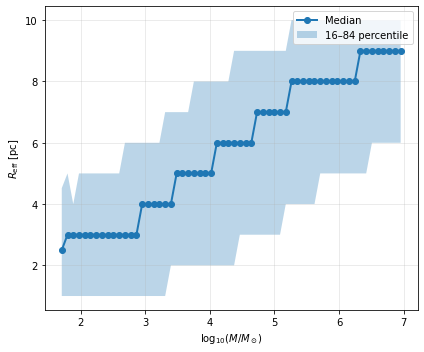

In [37]:
import numpy as np
import matplotlib.pyplot as plt

logM = np.log10(all_mass)

nbins = 60
bins = np.linspace(logM.min(), logM.max(), nbins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

digit = np.digitize(logM, bins)

reff_med = np.array([
    np.median(all_reff[digit == i]) if np.any(digit == i) else np.nan
    for i in range(1, nbins + 1)
])

reff_p16 = np.array([
    np.percentile(all_reff[digit == i], 16) if np.any(digit == i) else np.nan
    for i in range(1, nbins + 1)
])

reff_p84 = np.array([
    np.percentile(all_reff[digit == i], 84) if np.any(digit == i) else np.nan
    for i in range(1, nbins + 1)
])

plt.figure(figsize=(6,5))

plt.plot(bin_centers, reff_med, marker="o", lw=2, label="Median")
plt.fill_between(
    bin_centers, reff_p16, reff_p84,
    alpha=0.3, label="16–84 percentile"
)

plt.xlabel(r"$\log_{10}(M/M_\odot)$")
plt.ylabel(r"$R_{\rm eff}$ [pc]")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [6]:
# 1. Deteced in white (use sex...coo for coordiantes comparison to flag detection)
# 2. Detected in ≥ 4 bands with error < 0.3 mag. (Except V band, use /photomety folder .coo files to get coordinates + mag _errr, pass these two, flag detection), needs V band magnitudes Brighter than MV = –6 mag (CI-based V-band).


In [30]:
# 2. Detected in ≥ 4 bands with error < 0.3 mag. (Except V band, use /photomety folder .coo files to get coordinates + mag _errr, pass these two, flag detection), needs V band magnitudes Brighter than MV = –6 mag (CI-based V-band).
# Visualize photmetry .coo file structure 
example_coo_file = glob.glob('/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100/f814w/photometry/coo_ngc628-c_acsff814w_frame0_vframe_9_vset_17Nov_validation*')

In [33]:
x, y, mag, magerr = np.loadtxt(example_coo_file[0])[:, 0], np.loadtxt(example_coo_file[0])[:, 1], np.loadtxt(example_coo_file[0])[:, 2], np.loadtxt(example_coo_file[0])[:, 3]

In [34]:
mag

array([21.14155882, 18.64355882, 18.05355882, 20.53155882, 22.78155882,
       21.99655882, 22.24655882, 19.29955882, 19.57855882, 20.37455882,
       22.90755882, 17.98955882, 19.96055882, 18.73955882, 18.98555882,
       20.98455882, 20.04755882, 20.50655882, 19.85955882, 19.58755882,
       21.61055882, 21.96055882, 16.18955882, 19.04755882, 18.79455882,
       19.82155882, 17.97455882, 22.10855882, 19.88355882, 21.30655882,
       19.45455882, 16.17855882, 21.04955882, 22.04655882, 23.35255882,
       23.02255882, 16.82055882, 21.04755882, 21.23455882, 21.00755882,
       18.39655882, 21.11055882, 21.78155882, 21.75155882, 18.66355882,
       20.12755882, 20.21655882, 18.30055882, 19.30655882, 21.98955882,
       18.90155882, 16.77955882, 16.12055882, 16.27355882, 17.59155882,
       16.61555882, 23.23855882, 22.18155882, 18.51555882, 18.12655882,
       20.18955882, 17.01355882, 21.86755882, 17.27555882, 19.82055882,
       19.90155882, 21.11555882, 18.39755882, 22.51255882, 19.71

In [28]:
# how to verify if this cluster has been detected ? 
import numpy as np
import os
import glob
from scipy.spatial import cKDTree

# Constants
nframe_start = 0
nframe_end = 100
nframe = nframe_end-nframe_start
reff = 10
x_white = 500
thres_coor = 3
outname = 'vset_17Nov'
detection_filters = np.full((x_white, nframe, reff), 0, dtype=np.uint8)
validation = True
framenum = 0
# Directories
main_dir = '/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100'
dw = '/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100/white'
outdir = os.path.join(dw, "matched_coords")
os.makedirs(outdir, exist_ok=True)
filterlist = ['f435w', 'f275w', 'f336w', 'f814w', 'f555w']
# sex_ngc628-c_WFC3_UVISfF336W_frame0_vframe_99_vset_4Nov_validation_reff9.00.fits.coo
# white_position_5_vframe_99_vset_4Nov_validation_reff1.00.txt
# --- Loop over frames and radii ---
for filt in filter_list:
for re in range(1, reff + 1):
    for f in range(nframe_start, nframe_end):
        if filt != 'f555w':
            if validation:
                coo_files = glob.glob(os.path.join(
                    main_dir, f'{filt}/photometry/coo_ngc628-c*{filt}_frame{framenum}_vframe_{f}_{outname}_validation_reff{re:.2f}.fits.coo'))

            else:
                coo_files = glob.glob(os.path.join(
                    dire, f'{filt}/photometry/coo_ngc628-c*{filt}_frame{framenum}_{outname}_reff{re:.2f}.fits.coo'))
        else:
            if validation:
                coo_files = glob.glob(os.path.join(
                    main_dir, f'{filt}/CI/ci_cut_*ngc628-c*{filt}_frame{framenum}_vframe_{f}_{outname}_validation_reff{re:.2f}.fits.coo'))
            else:
                coo_files = glob.glob(os.path.join(
                    dire, f'{filt}/CI/ci_cut_*ngc628*{filt}_frame{framenum}_{outname}_reff{re:.2f}.fits.coo'))
                
        if validation:
            syn_cfiles = glob.glob(os.path.join(
                dw, f'white_position_{framenum}_vframe_{f}_{outname}_validation_reff{re:.2f}.txt'))
        else:
            syn_cfiles = glob.glob(os.path.join(
                dw, f'white_position_{f}_{outname}_reff{re:.2f}.txt'))

        if not sex_cfiles or not syn_cfiles:
            continue
            print('no file.')

        sex_c = np.loadtxt(sex_cfiles[0])
        syn_c = np.loadtxt(syn_cfiles[0])

        # Coordinates
        x_v, y_v, mag, mag_err = sex_c[:, 0], sex_c[:, 1], sex_c[:, 2], sex_c[:, 3]
        x_s, y_s = syn_c[:, 0], syn_c[:, 1]

        # Build KDTree for detections
        tree = cKDTree(np.column_stack((x_v, y_v)))

        # Query nearest neighbor for each synthetic point
        dist, idx = tree.query(np.column_stack((x_s, y_s)), distance_upper_bound=thres_coor)

        # Keep only valid matches (within threshold)
        mask = np.isfinite(dist) & (dist < thres_coor)
        
        # Also check if mag_err <= 0.3 
        mask_mag_err = mag_err <= 0.3 
        if '555w' in filt:
            mask_Vmag_limit = mag < 23.98 # Vband mags must <= 23.98
        detection_filters[:len(mask), f, re - 1] = mask.astype(np.uint8)

        # Extract matched coordinates in sex_c
        matched_coords = sex_c[idx[mask].astype(int)]

        

print("✅ Done. detection_white shape =", detection_white.shape)


In [36]:
import numpy as np
import os
import glob

# Constants
nframe_start = 0
nframe_end = 100
nframe = nframe_end - nframe_start
reff = 10
x_white = 500
filters = ["f275w", "f336w", "f435w", "f555w", "f814w"]
nf = len(filters)

# Output: same shape as detection_white
# 1 = passes filter criteria, 0 = fails
detection_filters_final = np.zeros((x_white, nframe, reff), dtype=np.uint8)

# Directories
main_dir = "/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100"
phot_dir = os.path.join(main_dir)  # photometry folders live inside main_dir
validation = True
framenum = 0

#MV cut 
D_MOD = 29.98 
MV_cut = -6 
V_LIMIT =  D_MOD+MV_cut


# Mapping filter → index
fidx = {f: i for i, f in enumerate(filters)}

# Loop over radii and frames
for re in range(1, reff + 1):
    for f in range(nframe_start, nframe_end):

        # Temporary storage: whether each synthetic cluster passed per filter
        good_filters = np.zeros((x_white, nf), dtype=np.uint8)

        for filt in filters:

            # Photometry .coo filename pattern
            if filt != "f555w":
                if validation:
                    coo_files = glob.glob(
                        os.path.join(
                            main_dir,
                            f"{filt}/photometry",
                            f"coo_ngc628-c*{filt}_frame{framenum}_vframe_{f}_vset_17Nov_validation_reff{re:.2f}.fits.coo",
                        )
                    )
                else:
                    coo_files = glob.glob(
                        os.path.join(
                            main_dir,
                            f"{filt}/photometry",
                            f"coo_ngc628-c*{filt}_frame{f}_vset_17Nov_reff{re:.2f}.fits.coo",
                        )
                    )
            else:
                # V-band special CI folder
                if validation:
                    coo_files = glob.glob(
                        os.path.join(
                            main_dir,
                            f"{filt}/CI",
                            f"ci_cut_*ngc628-c*{filt}_frame{framenum}_vframe_{f}_vset_17Nov_validation_reff{re:.2f}.fits.coo",
                        )
                    )
                else:
                    coo_files = glob.glob(
                        os.path.join(
                            main_dir,
                            f"{filt}/CI",
                            f"ci_cut_*ngc628-c*{filt}_frame{f}_vset_17Nov_reff{re:.2f}.fits.coo",
                        )
                    )

            if not coo_files:
                continue

            sex_c = np.loadtxt(coo_files[0])   # (N_detected, 4) x y mag mag_err
            if sex_c.ndim == 1:
                sex_c = sex_c[None, :]

            # Extract magnitude & mag_err
            mag = sex_c[:, 2]
            mag_err = sex_c[:, 3]

            # --- Photometric quality mask ---
            mask = mag_err <= 0.3

            # --- V-band special absolute magnitude cut ---
            if filt == "f555w":
                MV = mag 
                mask &= (MV < V_LIMIT)

            # Save result into good_filters matrix
            # Only as many rows as synthetic sources (pad if fewer detections)
            nn = min(len(mask), x_white)
            good_filters[:nn, fidx[filt]] = mask[:nn].astype(np.uint8)

        # Count filters per synthetic cluster
        N_good = good_filters.sum(axis=1)   # shape: (x_white,)

        # Store result: ≥4 filters good → 1, else 0
        detection_filters_final[:, f, re - 1] = (N_good >= 4).astype(np.uint8)


print("✔ detection_filters_final shape =", detection_filters_final.shape)


KeyboardInterrupt: 

In [3]:
import numpy as np
import os
import glob
from scipy.spatial import cKDTree

# Constants
nframe_start = 0
nframe_end = 160
nframe = nframe_end - nframe_start
reff = 10
x_white = 500
thres_coor = 3
outname = "tset_18Dec"
validation = False

# Output matrices
detection_white = np.zeros((x_white, nframe, reff), dtype=np.uint8)
detected_index = {}  # (frame, re) → synthetic index list

# Directories
sex_dir = "/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100/white/s_extraction"
white_dir = "/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100/white"
matched_out = os.path.join(white_dir, "matched_coords")
os.makedirs(matched_out, exist_ok=True)

for re in range(1, reff + 1):
    for f in range(nframe_start, nframe_end):

        # ---- SEXTRACTOR COORD FILE ----
        if validation:
            sex_pattern = (
                f"sex_ngc628-c_WFC3_UVISfF336W_frame{framenum}_vframe_{f}_"
                f"{outname}_validation_reff{re:.2f}.fits.coo"
            )
        else:
            sex_pattern = (
                f"sex_ngc628-c_WFC3_UVISfF336W_frame{f}_{outname}_reff{re:.2f}.fits.coo"
            )

        sex_files = glob.glob(os.path.join(sex_dir, sex_pattern))

        # ---- synthetic positions ----
        if validation:
            syn_pattern = (
                f"white_position_{framenum}_vframe_{f}_{outname}_validation_reff{re:.2f}.txt"
            )
        else:
            syn_pattern = f"white_position_{f}_{outname}_reff{re:.2f}.txt"

        syn_files = glob.glob(os.path.join(white_dir, syn_pattern))

        if not sex_files or not syn_files:
            continue

        sex_c = np.loadtxt(sex_files[0])
        syn_c = np.loadtxt(syn_files[0])

        # Extract positions
        x_v, y_v = sex_c[:, 0], sex_c[:, 1]
        x_s, y_s = syn_c[:, 0], syn_c[:, 1]

        # KDTree match
        tree = cKDTree(np.column_stack((x_v, y_v)))
        dist, idx = tree.query(np.column_stack((x_s, y_s)), distance_upper_bound=thres_coor)

        mask = np.isfinite(dist) & (dist < thres_coor)
        detection_white[:, f, re - 1] = mask.astype(np.uint8)

        # Save detected synthetic indices
        detected_index[(f, re)] = np.where(mask)[0]

# print("White detection done:", detection_white.shape)
# np.save("detection_white_tset_18Dec.npy", detection_white)
# np.save("DETECTED_INDEX_tset_18Dec.npy", detected_index)


In [4]:
np.shape(detection_white)

(500, 160, 10)

In [5]:
np.sum(detection_white)/(20*10*500)

4.96162

In [6]:
import numpy as np
import os
import glob
from scipy.spatial import cKDTree

filters = ["f275w", "f336w", "f435w", "f555w", "f814w"]
nf = len(filters)

# Constants
nframe = 160
reff = 10
x_white = 500
validation = False
main_dir = "/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100"

# detected_index[(frame, reff)] = array of synthetic IDs detected in white
# detected_index = np.load("DETECTED_INDEX.npy", allow_pickle=True).item()

# Output matrix
detection_filters = np.zeros((x_white, nframe, reff), dtype=np.uint8)

# Absolute magnitude cut
D_MOD = 29.98
MV_cut = -6
V_LIMIT = D_MOD + MV_cut

for re in range(1, reff + 1):
    for f in range(nframe):

        # ---- white-detected synthetic IDs ----
        syn_ids = detected_index.get((f, re), np.array([], dtype=int))
        if len(syn_ids) == 0:
            continue

        # ---- load matched white coords (reference space!) ----
        matched_file = os.path.join(
            main_dir,
            "white/matched_coords",
            f"matched_frame{f}_tset_18Dec_reff{re:.2f}.txt"
        )
        if not os.path.exists(matched_file):
            continue

        matched_c = np.loadtxt(matched_file)[:, :2]

        # sanity check: matched coords must align with syn_ids
        if matched_c.shape[0] != len(syn_ids):
            raise RuntimeError(
                f"Mismatch: matched coords {matched_c.shape[0]} != syn_ids {len(syn_ids)} "
                f"(frame={f}, reff={re})"
            )

        # Track filter-level detection (only for white-detected ones)
        good = np.zeros((len(syn_ids), nf), dtype=np.uint8)

        for j, filt in enumerate(filters):

            # ---- locate filter coo file (only contains PASSING objects) ----
            if filt != "f555w":
                pattern = (
                    f"{filt}/photometry/"
                    f"coo_ngc628-c*{filt}_frame{f}_tset_18Dec_reff{re:.2f}.fits.coo"
                )
            else:
                pattern = (
                    f"{filt}/CI/"
                    f"ci_cut_*ngc628-c*{filt}_frame{f}_tset_18Dec_reff{re:.2f}.fits.coo"
                )

            files = glob.glob(os.path.join(main_dir, pattern))
            if not files:
                continue

            sex_c = np.loadtxt(files[0])
            if sex_c.ndim == 1:
                sex_c = sex_c[None, :]

            # ---- KDTree: does this white object have a valid photometry in this filter? ----
            tree = cKDTree(sex_c[:, :2])
            dist, idx = tree.query(matched_c, distance_upper_bound=3)

            detect_mask = np.isfinite(dist) & (dist < 3)

            # ---- photometric QC ----
            if detect_mask.any():
                mags = sex_c[idx[detect_mask], 2]
                magerr = sex_c[idx[detect_mask], 3]

                qc = magerr <= 0.3
                if filt == "f555w":
                    qc &= (mags < V_LIMIT)

                detect_mask[detect_mask] &= qc

            good[:, j] = detect_mask.astype(np.uint8)

        # ---- ≥4 filters requirement ----
        N_good = good.sum(axis=1)
        detection_filters[syn_ids, f, re - 1] = (N_good >= 4).astype(np.uint8)

# np.save("detection_filters_tset_18Dec.npy", detection_filters)
# print("✔ detection_filters shape =", detection_filters.shape)


array([[[0, 0, 1, ..., 1, 1, 1],
        [1, 0, 0, ..., 1, 1, 1],
        [0, 0, 1, ..., 1, 1, 0],
        ...,
        [0, 1, 1, ..., 1, 1, 0],
        [1, 1, 0, ..., 1, 1, 0],
        [0, 0, 1, ..., 1, 1, 0]],

       [[0, 1, 0, ..., 0, 0, 1],
        [0, 0, 1, ..., 1, 1, 1],
        [0, 0, 1, ..., 0, 1, 1],
        ...,
        [1, 0, 0, ..., 1, 1, 1],
        [0, 0, 1, ..., 0, 1, 1],
        [0, 1, 0, ..., 0, 0, 1]],

       [[0, 1, 1, ..., 0, 0, 1],
        [0, 0, 0, ..., 1, 1, 0],
        [1, 1, 0, ..., 1, 1, 0],
        ...,
        [0, 0, 0, ..., 1, 0, 1],
        [1, 0, 1, ..., 1, 1, 1],
        [0, 1, 0, ..., 1, 0, 0]],

       ...,

       [[0, 1, 0, ..., 1, 1, 1],
        [0, 0, 1, ..., 1, 0, 0],
        [0, 0, 0, ..., 1, 0, 0],
        ...,
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 0, 1, 0]],

       [[0, 1, 1, ..., 1, 1, 1],
        [0, 1, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1],
        ...,
        [0, 0, 0, ..., 

In [14]:
import numpy as np
import os
import glob
from scipy.spatial import cKDTree

filters = ["f275w", "f336w", "f435w", "f555w", "f814w"]
nf = len(filters)

# Constants
nframe = 20
reff = 10
x_white = 500
validation = False
main_dir = "/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100"

# # Load white index mapping
# detected_index = np.load("DETECTED_INDEX.npy", allow_pickle=True).item()

# Output matrix
detection_filters = np.zeros((x_white, nframe, reff), dtype=np.uint8)

# Absolute magnitude cut
D_MOD = 29.98
MV_cut = -6
V_LIMIT = D_MOD + MV_cut

for re in range(1, reff + 1):
    for f in range(nframe):

        # Synthetic IDs detected from Step 1
        syn_ids = detected_index.get((f, re), np.array([], dtype=int))
        if len(syn_ids) == 0:
            continue

        # Load synthetic coords again
        syn_file = glob.glob(
            os.path.join(main_dir, "white",
                f"white_position_{f}_tset_18Dec_reff{re:.2f}.txt")
        )[0]
        syn_c = np.loadtxt(syn_file)
        x_s, y_s = syn_c[:, 0], syn_c[:, 1]

        # Track good filters
        good = np.zeros((len(syn_ids), nf), dtype=np.uint8)

        for j, filt in enumerate(filters):

            # Find filter SEX coo file
            if filt != "f555w":
                pattern = f"{filt}/photometry/coo_ngc628-c*{filt}_frame{f}_tset_18Dec_reff{re:.2f}.fits.coo"
            else:
                pattern = f"{filt}/CI/ci_cut_*ngc628-c*{filt}_frame{f}_tset_18Dec_reff{re:.2f}.fits.coo"

            files = glob.glob(os.path.join(main_dir, pattern))
            if not files:
                continue

            sex_c = np.loadtxt(files[0])
            if sex_c.ndim == 1:
                sex_c = sex_c[None, :]

            # Build KDTree for matching
            tree = cKDTree(sex_c[:, :2])

            # Only match synthetic that were detected in white
            query_pos = syn_c[syn_ids, :2]
            dist, idx = tree.query(query_pos, distance_upper_bound=3)

            # Valid detections
            detect_mask = np.isfinite(dist) & (dist < 3)

            # Magnitude QC
            if detect_mask.any():
                mags = sex_c[idx[detect_mask], 2]
                magerr = sex_c[idx[detect_mask], 3]

                qc = magerr <= 0.3

                if filt == "f555w":
                    qc &= (mags < V_LIMIT)

                detect_mask[detect_mask] &= qc

            # Save into good filters array
            good[:, j] = detect_mask.astype(np.uint8)

        # Good if ≥ 4 filters
        N_good = good.sum(axis=1)
        detection_filters[syn_ids, f, re - 1] = (N_good >= 4).astype(np.uint8)

# np.save("detection_filters_tset_18Dec.npy", detection_filters)
# print("✔ detection_filters shape =", detection_filters.shape)


In [8]:
# detection_white = np.load("detection_white_tset_18Dec.npy")
# detection_filters = np.load("detection_filters_tset_18Dec.npy")

final_detection = detection_filters
# np.save("final_detection_tset_18Dec.npy", final_detection)

print("Final completeness cube:", final_detection.shape)

Final completeness cube: (500, 160, 10)


In [10]:
np.save("detection_tset_13Jan.npy", detection_filters)

In [13]:
np.load('allprop_28Nov_final.npz.npy', allow_pickle=True)

array({'mass': array([1.58688303e+02, 1.54374801e+04, 2.68161630e+06, ...,
       5.39459220e+04, 2.33981729e+03, 8.42525409e+04]), 'age': array([1.44661619e+05, 1.52711146e+09, 7.45605540e+08, ...,
       2.18153386e+06, 3.55240641e+09, 6.71767758e+05]), 'av': array([2.98985933, 2.97648979, 2.70418787, ..., 2.8914373 , 1.38608098,
       2.34458253]), 'phot': array([[28.35166142, 27.81830983, 28.57819392, 27.96276595, 26.65893887],
       [31.81349485, 29.79171388, 28.82922287, 27.29459884, 24.63696054],
       [24.48202799, 22.86144335, 21.9862184 , 20.84306663, 18.90373164],
       ...,
       [22.09113259, 21.57216363, 22.3552821 , 21.63508137, 20.14863149],
       [32.19266092, 30.48109928, 30.08838825, 29.05124154, 27.59362935],
       [20.66455085, 20.36867627, 21.30084551, 20.78374794, 19.53160114]])},
      dtype=object)

In [15]:
np.load('allprop_18Dec_final.npz.npy', allow_pickle=True)

FileNotFoundError: [Errno 2] No such file or directory: 'allprop_18Dec_final.npz.npy'

In [10]:
np.sum(detection_filters)/(500*20*10)

0.42163

In [5]:
import numpy as np
import os
import glob
from scipy.spatial import cKDTree

# Constants
nframe_start = 0
nframe_end = 100
nframe = nframe_end - nframe_start
reff = 10
x_white = 500
thres_coor = 3
outname = "tset_18Dec"
validation = True
framenum = 24

# Output matrices
detection_white = np.zeros((x_white, nframe, reff), dtype=np.uint8)
detected_index = {}  # (frame, re) → synthetic index list

# Directories
sex_dir = "/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100/white/s_extraction"
white_dir = "/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100/white"
matched_out = os.path.join(white_dir, "matched_coords")
os.makedirs(matched_out, exist_ok=True)

for re in range(1, reff + 1):
    for f in range(nframe_start, nframe_end):

        # ---- SEXTRACTOR COORD FILE ----
        if validation:
            sex_pattern = (
                f"sex_ngc628-c_WFC3_UVISfF336W_frame{framenum}_vframe_{f}_"
                f"{outname}_validation_reff{re:.2f}.fits.coo"
            )
        else:
            sex_pattern = (
                f"sex_ngc628-c_WFC3_UVISfF336W_frame{f}_{outname}_reff{re:.2f}.fits.coo"
            )

        sex_files = glob.glob(os.path.join(sex_dir, sex_pattern))

        # ---- synthetic positions ----
        if validation:
            syn_pattern = (
                f"white_position_{framenum}_vframe_{f}_{outname}_validation_reff{re:.2f}.txt"
            )
        else:
            syn_pattern = f"white_position_{f}_{outname}_reff{re:.2f}.txt"

        syn_files = glob.glob(os.path.join(white_dir, syn_pattern))

        if not sex_files or not syn_files:
            continue

        sex_c = np.loadtxt(sex_files[0])
        syn_c = np.loadtxt(syn_files[0])

        # Extract positions
        x_v, y_v = sex_c[:, 0], sex_c[:, 1]
        x_s, y_s = syn_c[:, 0], syn_c[:, 1]

        # KDTree match
        tree = cKDTree(np.column_stack((x_v, y_v)))
        dist, idx = tree.query(np.column_stack((x_s, y_s)), distance_upper_bound=thres_coor)

        mask = np.isfinite(dist) & (dist < thres_coor)
        detection_white[:, f, re - 1] = mask.astype(np.uint8)

        # Save detected synthetic indices
        detected_index[(f, re)] = np.where(mask)[0]

print("White detection done:", detection_white.shape)
np.save("detection_white_validation_18Dec.npy", detection_white)
np.save("DETECTED_INDEX_validation_18Dec.npy", detected_index)


White detection done: (500, 100, 10)


In [11]:
import numpy as np
import os
import glob
from scipy.spatial import cKDTree

filters = ["f275w", "f336w", "f435w", "f555w", "f814w"]
nf = len(filters)

# Constants
nframe = 100
reff = 10
x_white = 500
validation = True
framenum = 24
main_dir = "/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100"

# # Load white index mapping
# detected_index = np.load("DETECTED_INDEX.npy", allow_pickle=True).item()

# Output matrix
detection_filters = np.zeros((x_white, nframe, reff), dtype=np.uint8)

# Absolute magnitude cut
D_MOD = 29.98
MV_cut = -6
V_LIMIT = D_MOD + MV_cut

for re in range(1, reff + 1):
    for f in range(nframe):

        # Synthetic IDs detected from Step 1
        syn_ids = detected_index.get((f, re), np.array([], dtype=int))
        if len(syn_ids) == 0:
            continue

        # Load synthetic coords again
        syn_file = glob.glob(
            os.path.join(main_dir, "white",
                f"white_position_{framenum}_vframe_{f}_tset_18Dec_validation_reff{re:.2f}.txt")
        )[0]
        syn_c = np.loadtxt(syn_file)
        x_s, y_s = syn_c[:, 0], syn_c[:, 1]

        # Track good filters
        good = np.zeros((len(syn_ids), nf), dtype=np.uint8)

        for j, filt in enumerate(filters):

            # Find filter SEX coo file
            if filt != "f555w":
                pattern = f"{filt}/photometry/coo_ngc628-c*{filt}_frame{framenum}_vframe_{f}_tset_18Dec_validation_reff{re:.2f}.fits.coo"
            else:
                pattern = f"{filt}/CI/ci_cut_*ngc628-c*{filt}_frame{framenum}_vframe_{f}_tset_18Dec_validation_reff{re:.2f}.fits.coo"

            files = glob.glob(os.path.join(main_dir, pattern))
            if not files:
                continue

            sex_c = np.loadtxt(files[0])
            if sex_c.ndim == 1:
                sex_c = sex_c[None, :]

            # Build KDTree for matching
            tree = cKDTree(sex_c[:, :2])

            # Only match synthetic that were detected in white
            query_pos = syn_c[syn_ids, :2]
            dist, idx = tree.query(query_pos, distance_upper_bound=3)

            # Valid detections
            detect_mask = np.isfinite(dist) & (dist < 3)

            # Magnitude QC
            if detect_mask.any():
                mags = sex_c[idx[detect_mask], 2]
                magerr = sex_c[idx[detect_mask], 3]

                qc = magerr <= 0.3

                if filt == "f555w":
                    qc &= (mags < V_LIMIT)

                detect_mask[detect_mask] &= qc

            # Save into good filters array
            good[:, j] = detect_mask.astype(np.uint8)

        # Good if ≥ 4 filters
        N_good = good.sum(axis=1)
        detection_filters[syn_ids, f, re - 1] = (N_good >= 4).astype(np.uint8)

np.save("detection_filters_validation_tset_18Dec.npy", detection_filters)
print("✔ detection_filters shape =", detection_filters.shape)


✔ detection_filters shape = (500, 100, 10)


In [5]:
detection_white = np.load("detection_white_tset_18Dec.npy")
detection_filters = np.load("detection_filters_tset_18Dec.npy")

final_detection = (detection_white & detection_filters).astype(np.uint8)
np.save("final_detection_tset_18Dec.npy", final_detection)

print("Final completeness cube:", final_detection.shape)

Final completeness cube: (500, 160, 10)


In [8]:
import os
import glob
import numpy as np

path_npy = "/g/data/jh2/jt4478/make_LC_copy/physprop"

MAX_REFF = 10
MAX_FRAME = 20
CLUSTERS_PER_FRAME = 500
VALIDATION = False
outname = 'tset_18Dec'
mass_all = np.zeros(np.shape(final_detection))
age_all  = np.zeros(np.shape(final_detection))
av_all   = np.zeros(np.shape(final_detection))
phot_all = np.zeros((np.shape(final_detection)[0], np.shape(final_detection)[1], np.shape(final_detection)[2], 5))

def load_one_file(pattern):
    """Expect exactly one file. Raise error otherwise."""
    files = glob.glob(pattern)
    print(files)
    if len(files) != 1:
        raise RuntimeError(f"Expected 1 file, found {len(files)}: {pattern}")
    return np.load(files[0])

for reff in range(1, MAX_REFF + 1):
    for frame in range(MAX_FRAME):

        # ---------- MASS ----------
        mass_pattern = os.path.join(
            path_npy,
            f"mass*modelKr*_frame{frame}_reff{reff}_{outname}.npy"
        )
        mass_arr = load_one_file(mass_pattern).ravel()
        if mass_arr.size != CLUSTERS_PER_FRAME:
            raise RuntimeError(f"mass size != 500 at frame {frame}, reff {reff}")
        mass_all[:, frame, reff-1] = mass_arr

        # ---------- AGE ----------
        age_pattern = os.path.join(
            path_npy,
            f"age*Kr*_frame{frame}_reff{reff}_{outname}.npy"
        )
        age_arr = load_one_file(age_pattern).ravel()
        if age_arr.size != CLUSTERS_PER_FRAME:
            raise RuntimeError(f"age size != 500 at frame {frame}, reff {reff}")
        age_all[:, frame, reff-1] = age_arr

        # ---------- AV ----------
        av_pattern = os.path.join(
            path_npy,
            f"av*Kr*_frame{frame}_reff{reff}_{outname}.npy"
        )
        av_arr = load_one_file(av_pattern).ravel()
        if av_arr.size != CLUSTERS_PER_FRAME:
            raise RuntimeError(f"av size != 500 at frame {frame}, reff {reff}")
        av_all[:, frame, reff-1] = av_arr

        # ---------- MAG ----------
        mag_pattern = os.path.join(
            path_npy,
            f"mag_VEGA_*Kr*_frame{frame}_reff{reff}_{outname}.npy"
        )
        mag_arr = load_one_file(mag_pattern)
        if mag_arr.shape[0] != CLUSTERS_PER_FRAME:
            raise RuntimeError(f"mag rows != 500 at frame {frame}, reff {reff}")
        phot_all[:, frame, reff-1, :] =  mag_arr

#     # concatenate in strictly ordered (frame0, frame1, ..., frame9)
#     mass_all[reff] = np.concatenate(mass_list)     # shape = (5000,)
#     age_all[reff]  = np.concatenate(age_list)     # shape = (5000,)
#     av_all[reff]   = np.concatenate(av_list)     # shape = (5000,)
#     mag_all[reff]  = np.concatenate(mag_list)     # shape = (5000, nf)

print("✔ physprop saving finished (frame-aligned).")


['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame0_reff1_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame0_reff1_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame0_reff1_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame0_reff1_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame1_reff1_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame1_reff1_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame1_reff1_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame1_reff1_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame2_reff1_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame2_reff1_tset_1

['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame0_reff2_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame0_reff2_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame1_reff2_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame1_reff2_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame1_reff2_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame1_reff2_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame2_reff2_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame2_reff2_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame2_reff2_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame2_reff2_tse

['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame1_reff3_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame1_reff3_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame1_reff3_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame1_reff3_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame2_reff3_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame2_reff3_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame2_reff3_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame2_reff3_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame3_reff3_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame3_reff3_tset_1

['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame2_reff4_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame2_reff4_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame2_reff4_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame3_reff4_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame3_reff4_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame3_reff4_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame3_reff4_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame4_reff4_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame4_reff4_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame4_reff4_tset_18D

['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame2_reff5_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame2_reff5_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame3_reff5_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame3_reff5_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame3_reff5_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame3_reff5_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame4_reff5_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame4_reff5_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame4_reff5_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame4_reff5_tse

['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame3_reff6_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame3_reff6_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame4_reff6_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame4_reff6_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame4_reff6_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame4_reff6_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame5_reff6_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame5_reff6_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame5_reff6_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame5_reff6_tse

['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame4_reff7_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame4_reff7_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame5_reff7_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame5_reff7_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame5_reff7_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame5_reff7_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame6_reff7_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame6_reff7_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame6_reff7_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame6_reff7_tse

['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame4_reff8_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame5_reff8_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame5_reff8_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame5_reff8_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame5_reff8_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame6_reff8_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame6_reff8_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame6_reff8_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame6_reff8_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame7_reff8_t

['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame5_reff9_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame5_reff9_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame6_reff9_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame6_reff9_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame6_reff9_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame6_reff9_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame7_reff9_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame7_reff9_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame7_reff9_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame7_reff9_tse

['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame6_reff10_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame6_reff10_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame7_reff10_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame7_reff10_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame7_reff10_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame7_reff10_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelKrumholz19_frame8_reff10_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/age_select_modelKrumholz19_frame8_reff10_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/av_select_modelKrumholz19_frame8_reff10_tset_18Dec.npy']
['/g/data/jh2/jt4478/make_LC_copy/physprop/mag_VEGA_select_modelKrumholz19_frame8_

In [16]:
final_detection

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Choose filter (V-band)
# -------------------------
filters = ["f275w", "f336w", "f435w", "f555w", "f814w"]
filt = "f555w"
fidx = filters.index(filt)

# -------------------------
# Flatten everything
# -------------------------
# mag: (N,)
mag = phot_all[..., fidx].ravel()

# detection: (N,)
det = final_detection.ravel()

# sanity
assert mag.shape == det.shape

# -------------------------
# Bin in magnitude
# -------------------------
bins = np.arange(np.nanmin(mag), np.nanmax(mag) + 0.2, 0.2)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

det_frac = np.zeros(len(bin_centers))
counts   = np.zeros(len(bin_centers), dtype=int)

for i in range(len(bin_centers)):
    m = (mag >= bins[i]) & (mag < bins[i+1])
    counts[i] = m.sum()
    if counts[i] > 0:
        det_frac[i] = det[m].mean()
    else:
        det_frac[i] = np.nan

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(6,4))
plt.plot(bin_centers, det_frac, marker="o", lw=2)
plt.xlabel(f"{filt} magnitude (VEGA)")
plt.ylabel("Detection fraction")
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.title(f"Detection completeness vs magnitude ({filt})")
plt.show()


NameError: name 'phot_all' is not defined

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Flatten
# -------------------------
mag = phot_all[..., fidx].ravel()

det_white = detection_white.ravel()
det_final = final_detection.ravel()

assert mag.shape == det_white.shape == det_final.shape

# -------------------------
# Bin in magnitude
# -------------------------
bins = np.arange(np.nanmin(mag), np.nanmax(mag) + 0.2, 0.2)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

frac_white = np.zeros(len(bin_centers))
frac_final = np.zeros(len(bin_centers))
counts     = np.zeros(len(bin_centers), dtype=int)

for i in range(len(bin_centers)):
    m = (mag >= bins[i]) & (mag < bins[i+1])
    counts[i] = m.sum()
    if counts[i] > 0:
        frac_white[i] = det_white[m].mean()
        frac_final[i] = det_final[m].mean()
    else:
        frac_white[i] = np.nan
        frac_final[i] = np.nan

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(6.5,4.5))
plt.plot(bin_centers, frac_white, marker="o", lw=2, label="White detection only")
plt.plot(bin_centers, frac_final, marker="o", lw=2, label="White + filters")

plt.xlabel("f555w magnitude (VEGA)")
plt.ylabel("Detection fraction")
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Detection completeness vs magnitude")

plt.show()


NameError: name 'phot_all' is not defined

In [8]:
np.save('detect_tset_18Dec.npy', detection_conca)

In [45]:
# Next step check if vset and tset have any overlapping clusters 

In [5]:
import numpy as np
import glob
import os


def load_all_arrays(pattern, path_npy):
    arrays = []
    for f in glob.glob(os.path.join(path_npy, pattern)):
        arr = np.load(f)
        arr = arr.reshape(arr.shape[0], -1)  # flatten each cluster
        arrays.append(arr)
    if not arrays:
        return np.empty((0,4))
    return np.vstack(arrays)

# ---- fastest: just load all vset and all tset ----
vset = load_all_arrays("mass*vset_17Nov*npy", path_npy)
tset = load_all_arrays("mass*tset_13Nov*.npy", path_npy)

print("VSET shape:", vset.shape)
print("TSET shape:", tset.shape)

# Convert rows to hashable tuples
vset_set = set(map(tuple, vset))
tset_set = set(map(tuple, tset))

# Intersection = overlapping clusters (BAD!)
overlap = vset_set & tset_set

print("\n Overlap count:", len(overlap))
if len(overlap) == 0:
    print("Split SUCCESS: training and validation sets are fully separate!")
else:
    print("Split FAILED: Found clusters appearing in BOTH sets!")


VSET shape: (185000, 1)
TSET shape: (740000, 1)

 Overlap count: 0
Split SUCCESS: training and validation sets are fully separate!


In [11]:
import os
import glob
import numpy as np

path_npy = "/g/data/jh2/jt4478/make_LC_copy/physprop"

MAX_REFF = 10
CLUSTERS_PER_FRAME = 500

mass_all = np.zeros((500, 10))
age_all  = np.zeros((500, 10))
av_all   = np.zeros((500, 10))
phot_all = np.zeros((500, 10, 5))

def load_one_file(pattern):
    """Expect exactly one file. Raise error otherwise."""
    files = glob.glob(pattern)
    if len(files) != 1:
        raise RuntimeError(f"Expected 1 file, found {len(files)}: {pattern}")
    return np.load(files[0])

for reff in range(1, MAX_REFF + 1):
    # ---------- MASS ----------
    mass_pattern = os.path.join(
        path_npy,
        f"mass*modelflat_frame24_reff{reff}_{outname}.npy"
    )
    mass_arr = load_one_file(mass_pattern).ravel()
    if mass_arr.size != CLUSTERS_PER_FRAME:
        raise RuntimeError(f"mass size != 500 at frame {frame}, reff {reff}")
    mass_all[:, reff-1] = mass_arr

    # ---------- AGE ----------
    age_pattern = os.path.join(
        path_npy,
        f"age*flat_frame0_reff{reff}_{outname}.npy"
    )
    age_arr = load_one_file(age_pattern).ravel()
    if age_arr.size != CLUSTERS_PER_FRAME:
        raise RuntimeError(f"age size != 500 at frame {frame}, reff {reff}")
    age_all[:, reff-1] = age_arr

    # ---------- AV ----------
    av_pattern = os.path.join(
        path_npy,
        f"av*flat_frame0_reff{reff}_{outname}.npy"
    )
    av_arr = load_one_file(av_pattern).ravel()
    if av_arr.size != CLUSTERS_PER_FRAME:
        raise RuntimeError(f"av size != 500 at frame {frame}, reff {reff}")
    av_all[:, reff-1] = av_arr

    # ---------- MAG ----------
    mag_pattern = os.path.join(
        path_npy,
        f"mag_VEGA_*flat_frame0_reff{reff}_{outname}.npy"
    )
    mag_arr = load_one_file(mag_pattern)
    if mag_arr.shape[0] != CLUSTERS_PER_FRAME:
        raise RuntimeError(f"mag rows != 500 at frame {frame}, reff {reff}")
    phot_all[:, reff-1, :] =  mag_arr

#     # concatenate in strictly ordered (frame0, frame1, ..., frame9)
#     mass_all[reff] = np.concatenate(mass_list)     # shape = (5000,)
#     age_all[reff]  = np.concatenate(age_list)     # shape = (5000,)
#     av_all[reff]   = np.concatenate(av_list)     # shape = (5000,)
#     mag_all[reff]  = np.concatenate(mag_list)     # shape = (5000, nf)

print("✔ physprop saving finished (frame-aligned).")


✔ physprop saving finished (frame-aligned).


In [12]:
all_prop = {}
all_prop['mass'] = np.concatenate(mass_all)
all_prop['age'] = np.concatenate(age_all)
all_prop['av'] = np.concatenate(av_all)
all_prop['phot'] = np.concatenate(phot_all)

In [14]:
np.save('all_prop_validation.npy', all_prop)

In [10]:
path_npy = '/g/data/jh2/jt4478/make_LC_copy/physprop'
# NEXT check: plot mass versus detection for validation sets 
mass_check_files = glob.glob(os.path.join(path_npy, 'mass*flat_frame0_reff*vset_17Nov.npy'))

In [11]:
mass_check_files.sort()

In [12]:
mass_check_files = []

for reff in range(1, 11):
    mass_check_files.append(glob.glob(os.path.join(path_npy, f'mass*flat_frame0_reff{reff}_*vset_17Nov.npy'))[0])


In [13]:
mass_check_files

['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelflat_frame0_reff1_vset_17Nov.npy',
 '/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelflat_frame0_reff2_vset_17Nov.npy',
 '/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelflat_frame0_reff3_vset_17Nov.npy',
 '/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelflat_frame0_reff4_vset_17Nov.npy',
 '/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelflat_frame0_reff5_vset_17Nov.npy',
 '/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelflat_frame0_reff6_vset_17Nov.npy',
 '/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelflat_frame0_reff7_vset_17Nov.npy',
 '/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelflat_frame0_reff8_vset_17Nov.npy',
 '/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelflat_frame0_reff9_vset_17Nov.npy',
 '/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelflat_frame0_reff10_vset_17Nov.npy']

In [14]:
mass_check_matrix = np.zeros((500, 10))
for i in range(mass_check_matrix.shape[-1]):
    mass_check_matrix[:, i] = np.load(mass_check_files[i])


In [17]:
final_detection_avg = np.mean(final_detection, axis=-2)

(500, 10)

In [23]:
final_detection_ = final_detection_avg.flatten()
mass_check_ = mass_check_matrix.flatten()

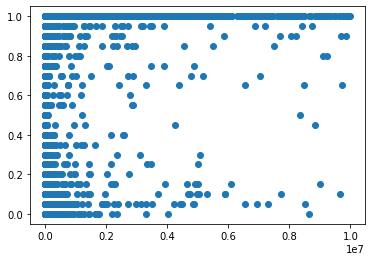

In [24]:
plt.scatter(mass_check_, final_detection_)

In [5]:
# next step: save the phys and photometric properties to a dict 
# we need to shuffle all radii to have this test 